In [7]:
#used for data manipulation and numerical operations:
import numpy as np
import pandas as pd
import joblib
#Used for predicting most frequently occuring value:
from scipy.stats import mode
# used for data visualization tasks:
import matplotlib.pyplot as plt
import seaborn as sns
#converts categorical labels(diseases) into numerical values:
from sklearn.preprocessing import LabelEncoder
#train_test_split: splits data into training and test sets and 
#cross_val_score: performs k-fold cross_ validation
from sklearn.model_selection import train_test_split, cross_val_score,StratifiedKFold
from collections import Counter
# machine learning models used for classification tasks:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
import statistics
# evaluation matrix for model performance:
from sklearn.metrics import accuracy_score, confusion_matrix

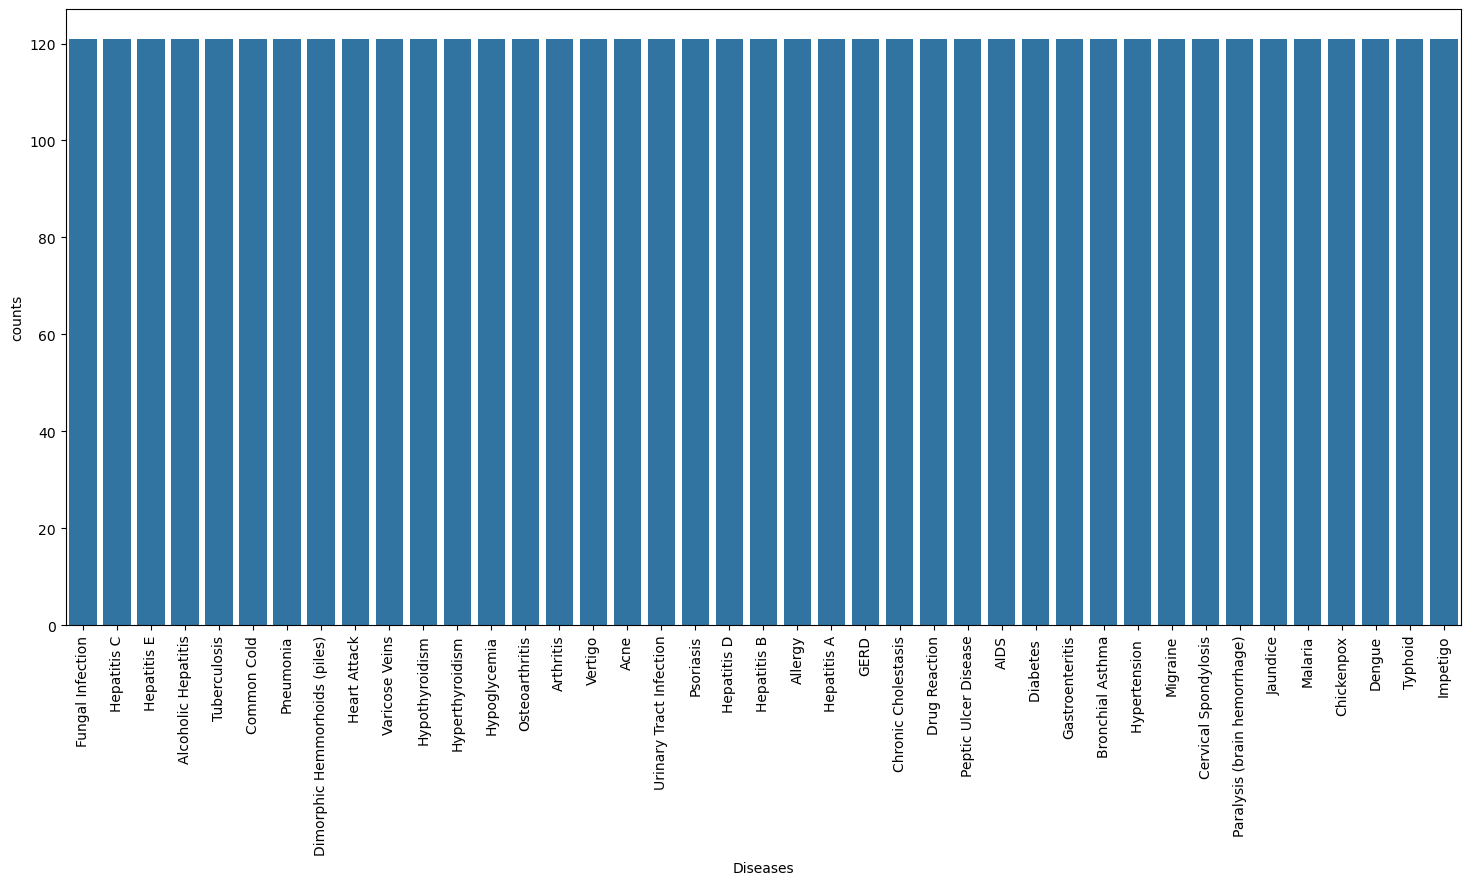

In [299]:
# Counting the occurrences of each disease:
disease_counts = data["prognosis"].value_counts()
#creating a dataframe for visualization:
temp_df = pd.DataFrame({
    "Diseases": disease_counts.index,
    "counts": disease_counts.values
})
# Setting figure size to plotting the bar graph:
plt.figure(figsize=(18,8))
# Setting x and y axis to plot the bar chart from the data(temp_df):
sns.barplot(x="Diseases",y="counts",data = temp_df)
# Rotating x-axis label for readability:
plt.xticks(rotation=90)
# for displaying the plot:
plt.show()

In [332]:
df = pd.read_csv(r"C:\Users\ranji\Downloads\symbipredict_2022.csv")  # Use the correct file path
X = df.iloc[:, :-1]  # All columns except the last one (Symptoms)
y = df.iloc[:, -1]   # The last column (Disease)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
joblib.dump(model, "disease_model.pkl")
print("Model saved as disease_model.pkl")


Model Accuracy: 100.00%
Model saved as disease_model.pkl


In [295]:
#Loading and preprocessing the dataset:
DATA_PATH = r"C:\Users\ranji\Downloads\symbipredict_2022.csv"
data = pd.read_csv(DATA_PATH).dropna(axis=1)

In [334]:
#initiate an instance for a preprocessing technique:
encoder = LabelEncoder()
# converting a categorical labels into a numerical values:
data["prognosis"] = encoder.fit_transform(data["prognosis"])

In [303]:
# extracting features and target values for splitting datasets:
x = data.iloc[:,:-1]
y = data.iloc[:,-1]
# splitting datasets for training and testing to prevent overfitting by evaluating the model:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=24)
print(x_train,x_test,y_train,y_test)

      itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  \
4872        0          0                     0                    0   
699         0          0                     0                    0   
830         0          0                     0                    1   
1814        0          0                     0                    0   
4425        0          0                     0                    0   
...       ...        ...                   ...                  ...   
2193        1          0                     0                    0   
3473        0          0                     0                    0   
343         0          0                     0                    0   
899         0          0                     0                    0   
4514        1          1                     0                    0   

      shivering  chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  \
4872          0       0           1             0        0         

In [305]:
# This is used for cheking that the cross validation tasks are performing well or not:
# finding each unique class labels and their counts:
unique, counts = np.unique(y,return_counts=True)
# Combining the labels and counts then converting them into a  dictionary for visualization:
class_distribution = dict(zip(unique, counts))
print("Class_distribution:",class_distribution)
# Finding the smallest class size to determine the number of
# splits for cross validation tasks:
min_class_size = min(counts)
n_splits = max(2,min(10,min_class_size))
print(f"Using {n_splits} splits for Cross_validation")

Class_distribution: {0: 121, 1: 121, 2: 121, 3: 121, 4: 121, 5: 121, 6: 121, 7: 121, 8: 121, 9: 121, 10: 121, 11: 121, 12: 121, 13: 121, 14: 121, 15: 121, 16: 121, 17: 121, 18: 121, 19: 121, 20: 121, 21: 121, 22: 121, 23: 121, 24: 121, 25: 121, 26: 121, 27: 121, 28: 121, 29: 121, 30: 121, 31: 121, 32: 121, 33: 121, 34: 121, 35: 121, 36: 121, 37: 121, 38: 121, 39: 121, 40: 121}
Using 10 splits for Cross_validation


In [308]:
# Encode categorical features
encoder = LabelEncoder()
for col in x.columns:
    x[col] = encoder.fit_transform(x[col])

# Encode target variable
y = encoder.fit_transform(y)

# Check class distribution
unique_classes, class_counts = np.unique(y, return_counts=True)
min_class_count = min(class_counts)

# Adjust n_splits based on the smallest class count
n_splits = min(5, min_class_count)  # Ensuring n_splits <= smallest class size

# Perform cross-validation
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=18)

# Define models
models = {
    "SVC": SVC(),
    "Gaussian NB": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=18)
}

# Iterate through models and evaluate accuracy
for model_name, model in models.items():
    scores = cross_val_score(model, x, y, cv=skf, n_jobs=-1, scoring='accuracy')
    print("=" * 30)
    print(model_name)
    print(f"Mean Accuracy: {np.mean(scores):.4f}")
    print(f"Standard Deviation: {np.std(scores):.4f}")

SVC
Mean Accuracy: 1.0000
Standard Deviation: 0.0000
Gaussian NB
Mean Accuracy: 1.0000
Standard Deviation: 0.0000
Random Forest
Mean Accuracy: 1.0000
Standard Deviation: 0.0000


Accuracy on train data by SVM Classifier: 95.50%
Accuracy on test data by SVM Classifier:95.93%


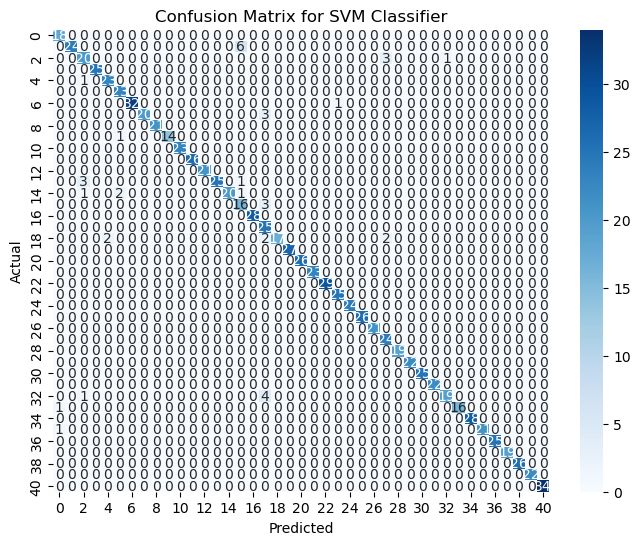

Accuracy on train data by Gaussian Naïve Bayes: 87.80%
Accuracy on test data by Gaussian Naïve Bayes:2.34%


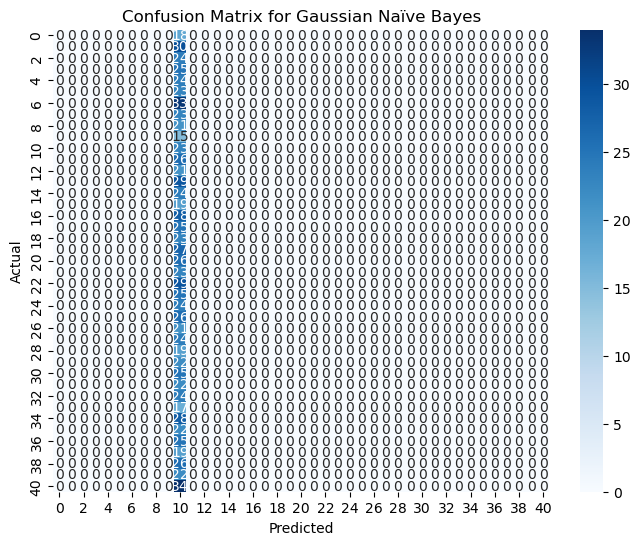

Accuracy on train data by Random Forest Classifier: 100.00%
Accuracy on test data by Random Forest Classifier:100.00%


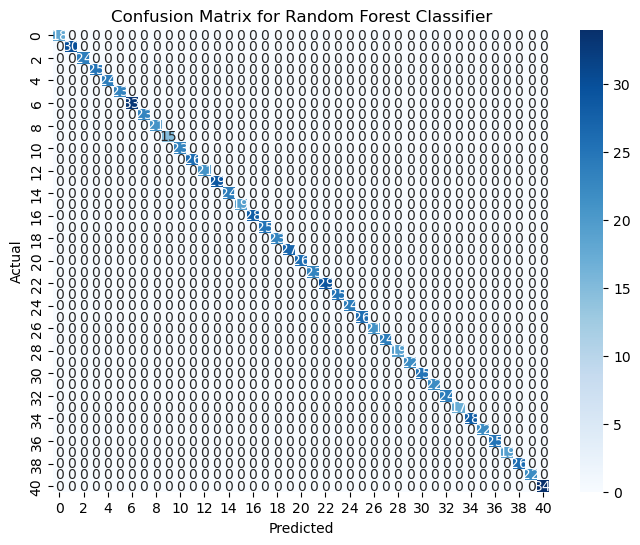

In [338]:
df = pd.read_csv(r"C:\Users\ranji\Downloads\disease prediction\dataset.csv")
x = df.drop(columns="Disease")
y = df["Disease"]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Ensure no spaces in categorical data
x_train = x_train.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))
x_test = x_test.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))

encoders = {}  # Dictionary to store encoders

# Encode categorical features
for col in x_train.columns:
    encoder = LabelEncoder()
    x_train[col] = encoder.fit_transform(x_train[col])

    # Ensure `x_test[col]` contains only known labels
    x_test[col] = x_test[col].map(lambda x: x if x in encoder.classes_ else "UNKNOWN")
    encoder.classes_ = np.append(encoder.classes_, "UNKNOWN")  # Add "UNKNOWN" class
    x_test[col] = encoder.transform(x_test[col])  

    encoders[col] = encoder

# Encode the target variable
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

def train_evaluate_model(model,model_name):
    model.fit(x_train, y_train)
    preds = model.predict(x_test)

    train_acc = accuracy_score(y_train,model.predict(x_train)) * 100
    test_acc = accuracy_score(y_test,preds) * 100
    
    print(f"Accuracy on train data by {model_name}: {train_acc:.2f}%")
    print(f"Accuracy on test data by {model_name}:{test_acc:.2f}%")
# Confusion Matrix
    cf_matrix = confusion_matrix(y_test, preds)

# Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix for {model_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

models = {
    "SVM Classifier": SVC(),
    "Gaussian Naïve Bayes": GaussianNB(),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name,model in models.items():
    train_evaluate_model(model,name)

In [312]:
# finalized model after preprocessing:
final_svm_model = SVC(probability=True)
final_nb_model = GaussianNB()
final_rf_model = RandomForestClassifier(n_estimators=100,random_state=18)
# Train a final model:
final_svm_model.fit(x_train,y_train)
final_nb_model.fit(x_train,y_train)
final_rf_model.fit(x_train,y_train)
#Predicting these with actual values(Target):
svm_preds = final_svm_model.predict(x_test)
nb_preds = final_nb_model.predict(x_test)
rf_preds = final_rf_model.predict(x_test)
# Doing ensemble handling for final predictions among those models:
final_preds = mode([svm_preds,nb_preds,rf_preds])[0].flatten()
# Displaying the most frequent prediction's accuracy in percent:
accuracy = accuracy_score(y_test,final_preds) * 100
print(f"Accuracy score on test dataset by the combined model : {accuracy:.2f}%")

Accuracy score on test dataset by the combined model : 97.36%


In [314]:
import numpy as np
import statistics

def PredictDisease(symptoms):
    symptoms = symptoms.lower().split(",")  # Convert to lowercase and split into list
    symptoms = [symptom.strip() for symptom in symptoms]  # Remove extra spaces

    input_data = [0] * len(data_dict["symptom_index"])  # Initialize input array

    found_symptoms = False  # Flag to check if valid symptoms are found
    for symptom in symptoms:
        if symptom in data_dict["symptom_index"]:
            index = data_dict["symptom_index"][symptom]
            input_data[index] = 1  # Mark symptom as present
            found_symptoms = True  # Mark valid symptoms found

    if not found_symptoms:  # If no valid symptoms were found
        return {"error": "No valid symptoms found. Please enter correct symptoms."}

    input_data = np.array(input_data).reshape(1, -1)  # Convert to NumPy array

    # Make individual model predictions
    rf_prediction = data_dict["predictions_classes"][final_rf_model.predict(input_data)[0]]
    nb_prediction = data_dict["predictions_classes"][final_nb_model.predict(input_data)[0]]
    svm_prediction = data_dict["predictions_classes"][final_svm_model.predict(input_data)[0]]

    # Majority voting
    final_prediction = statistics.mode([rf_prediction, nb_prediction, svm_prediction])

    # Return all predictions and the final predicted disease
    predictions = {
        "rf_model_prediction": rf_prediction,
        "naive_bayes_prediction": nb_prediction,
        "svm_model_prediction": svm_prediction,
        "final_prediction": final_prediction  # Disease predicted by majority vote
    }
    return predictions




In [11]:
# Load the dataset
df = pd.read_csv(r"C:\Users\ranji\Downloads\symbipredict_2022.csv")

# Load trained model (Ensure you have a trained model saved as 'disease_model.pkl')
model = joblib.load("disease_model.pkl")

# List of symptom columns (excluding 'prognosis' or 'disease' column)
symptom_columns = df.columns[:-1].tolist()

# Ask user for symptoms
user_symptoms = input("Enter symptoms separated by commas: ").strip().lower().split(",")

# Convert user input to binary format
user_input = np.zeros(len(symptom_columns), dtype=int)

for i, symptom in enumerate(symptom_columns):
    if symptom.lower() in user_symptoms:
        user_input[i] = 1

# Convert to DataFrame for prediction
user_input_df = pd.DataFrame([user_input], columns=symptom_columns)

# Predict disease
predicted_disease = model.predict(user_input_df)[0]

print(f"Predicted Disease: {predicted_disease}")

Enter symptoms separated by commas:  stomach pain


Predicted Disease: Arthritis
